# Step 1: Import Required Libraries

In this step, we import all the libraries required for downloading the dataset, image processing, feature extraction, machine learning, visualization, and model saving.

In [2]:
# ============================================================
# Step 1 : Import Required Libraries
# ============================================================

# Standard Libraries
import os
import zipfile
import random
import warnings

# Numerical Computing
import numpy as np

# Data Visualization
import matplotlib.pyplot as plt

# Image Processing
import cv2

# Kaggle Dataset Download
import kagglehub

# Feature Extraction
from skimage.feature import hog

# Machine Learning
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.svm import SVC
from sklearn.metrics import (
    accuracy_score,
    classification_report,
    confusion_matrix,
    ConfusionMatrixDisplay
)

# Model Saving
import joblib

warnings.filterwarnings("ignore")

print("=" * 60)
print("All libraries imported successfully!")
print("=" * 60)

c:\Shubranil\Internship\SkillCraft Technology\Machine Learning\Task - 2\.venv\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


All libraries imported successfully!


# Step 2: Download the Dogs vs Cats Dataset

In this step, we download the Dogs vs Cats dataset directly from Kaggle using the KaggleHub library.

This approach eliminates the need for manually downloading the dataset and storing it inside the project folder.

In [3]:
# The following code will only execute
# successfully when compression is complete

import kagglehub

# Download latest version
path = kagglehub.competition_download('dogs-vs-cats')

print("Path to competition files:", path)

Path to competition files: C:\Users\Shubranil\.cache\kagglehub\competitions\dogs-vs-cats


# Step 3: Explore the Dataset

In this step, we inspect the downloaded dataset to understand its folder structure and locate the training images.

In [4]:
# ============================================================
# Step 3 : Explore Dataset Structure
# ============================================================

import os

print("=" * 60)
print("Dataset Directory Structure")
print("=" * 60)

for root, dirs, files in os.walk(path):
    print(f"\n📁 {root}")

    for folder in dirs:
        print(f"   📂 {folder}")

    for file in files[:5]:      # Show first 5 files only
        print(f"   📄 {file}")

    print("-" * 60)

Dataset Directory Structure

📁 C:\Users\Shubranil\.cache\kagglehub\competitions\dogs-vs-cats
   📂 train
   📄 sampleSubmission.csv
   📄 test1.zip
   📄 train.zip
------------------------------------------------------------

📁 C:\Users\Shubranil\.cache\kagglehub\competitions\dogs-vs-cats\train
   📂 train
------------------------------------------------------------

📁 C:\Users\Shubranil\.cache\kagglehub\competitions\dogs-vs-cats\train\train
   📄 cat.0.jpg
   📄 cat.1.jpg
   📄 cat.10.jpg
   📄 cat.100.jpg
   📄 cat.1000.jpg
------------------------------------------------------------


# Step 4: Extract the Training Dataset

The downloaded dataset contains compressed ZIP files. In this step, we extract the training images so they can be used for preprocessing and model training.

In [5]:
# ============================================================
# Step 4 : Extract train.zip
# ============================================================

import os
import zipfile

train_zip = os.path.join(path, "train.zip")
extract_path = os.path.join(path, "train")

# Extract only if not already extracted
if not os.path.exists(extract_path):

    print("=" * 60)
    print("Extracting train.zip...")
    print("=" * 60)

    with zipfile.ZipFile(train_zip, "r") as zip_ref:
        zip_ref.extractall(extract_path)

    print("\n✅ Extraction Completed!")

else:
    print("✅ train.zip is already extracted.")

print("\nTraining Folder:")
print(extract_path)

✅ train.zip is already extracted.

Training Folder:
C:\Users\Shubranil\.cache\kagglehub\competitions\dogs-vs-cats\train


In [6]:
# ============================================================
# Step 5 : Verify Extraction
# ============================================================

import os

print("Extract Path:")
print(extract_path)

print("\nContents:")
print(os.listdir(extract_path))

nested_train = os.path.join(extract_path, "train")

print("\nNested Train Exists:", os.path.exists(nested_train))

if os.path.exists(nested_train):
    print("\nFirst 10 Images:")
    print(os.listdir(nested_train)[:10])

Extract Path:
C:\Users\Shubranil\.cache\kagglehub\competitions\dogs-vs-cats\train

Contents:
['train']

Nested Train Exists: True

First 10 Images:
['cat.0.jpg', 'cat.1.jpg', 'cat.10.jpg', 'cat.100.jpg', 'cat.1000.jpg', 'cat.10000.jpg', 'cat.10001.jpg', 'cat.10002.jpg', 'cat.10003.jpg', 'cat.10004.jpg']


# Step 6: Exploratory Data Analysis (EDA)

In this step, we explore the dataset before training the model.

We will:
- Count the number of cat and dog images.
- Display random sample images.
- Analyze image dimensions.
- Visualize the class distribution.

EDA helps us understand the dataset and identify any imbalance or inconsistencies before preprocessing.

In [7]:
# ============================================================
# Fix Training Path
# ============================================================

import os

train_path = os.path.join(path, "train", "train")

print("Training Path:")
print(train_path)

print("\nFirst 10 Files:")
print(os.listdir(train_path)[:10])

print("\nTotal Images:")
print(len(os.listdir(train_path)))

Training Path:
C:\Users\Shubranil\.cache\kagglehub\competitions\dogs-vs-cats\train\train

First 10 Files:
['cat.0.jpg', 'cat.1.jpg', 'cat.10.jpg', 'cat.100.jpg', 'cat.1000.jpg', 'cat.10000.jpg', 'cat.10001.jpg', 'cat.10002.jpg', 'cat.10003.jpg', 'cat.10004.jpg']

Total Images:
25000


In [8]:
# ============================================================
# Automatically Detect the Image Folder
# ============================================================

import os

possible_paths = [
    os.path.join(path, "train"),
    os.path.join(path, "train", "train")
]

for p in possible_paths:
    if os.path.exists(p):
        files = os.listdir(p)
        if len(files) > 0 and files[0].endswith(".jpg"):
            train_path = p
            break

print("Training Folder:")
print(train_path)

print("Total Images:", len(os.listdir(train_path)))

Training Folder:
C:\Users\Shubranil\.cache\kagglehub\competitions\dogs-vs-cats\train\train
Total Images: 25000


In [23]:
# ============================================================
# Step 6.1 : Dataset Summary
# ============================================================

image_files = os.listdir(train_path)

print("=" * 60)
print("Dataset Summary")
print("=" * 60)

print("Total Images :", len(image_files))

Dataset Summary
Total Images : 25000


In [24]:
# ============================================================
# Step 6.2 : Count Cat & Dog Images
# ============================================================

cat_count = sum(file.startswith("cat") for file in image_files)
dog_count = sum(file.startswith("dog") for file in image_files)

print(f"Cats : {cat_count}")
print(f"Dogs : {dog_count}")

Cats : 12500
Dogs : 12500


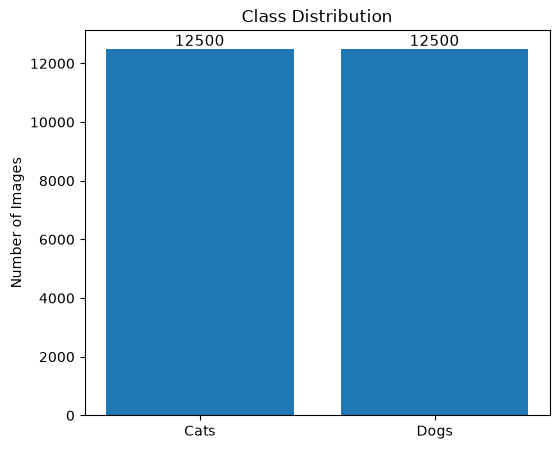

In [25]:
# ============================================================
# Step 6.3 : Visualize Class Distribution
# ============================================================

import matplotlib.pyplot as plt

plt.figure(figsize=(6,5))

bars = plt.bar(
    ["Cats","Dogs"],
    [cat_count,dog_count]
)

plt.title("Class Distribution")
plt.ylabel("Number of Images")

for bar in bars:
    plt.text(
        bar.get_x()+bar.get_width()/2,
        bar.get_height()+100,
        int(bar.get_height()),
        ha='center',
        fontsize=11
    )

plt.show()

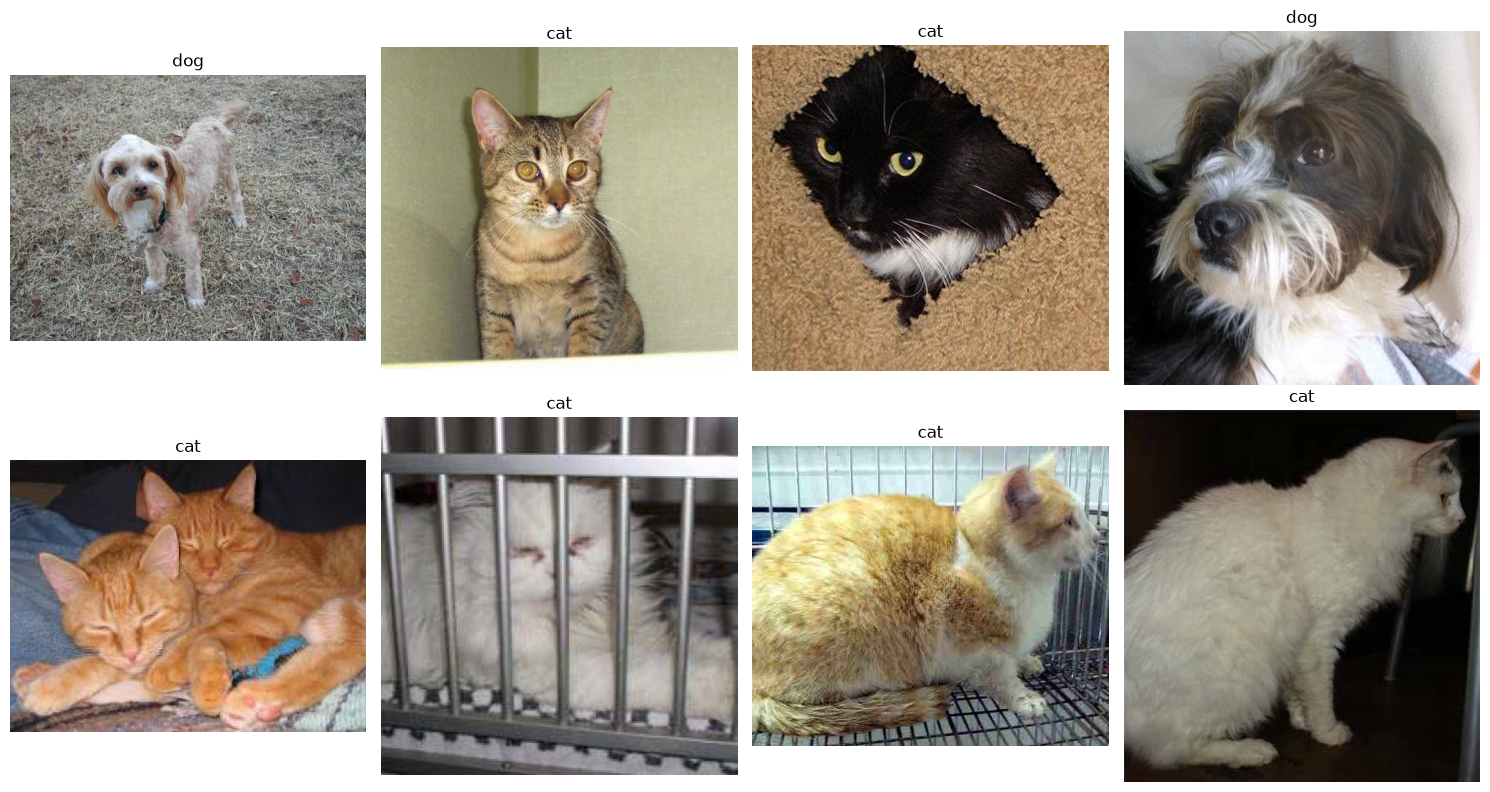

In [26]:
# ============================================================
# Step 6.4 : Display Random Images
# ============================================================

import random
import cv2

sample_images = random.sample(image_files,8)

plt.figure(figsize=(15,8))

for i,image_name in enumerate(sample_images):

    image = cv2.imread(os.path.join(train_path,image_name))
    image = cv2.cvtColor(image,cv2.COLOR_BGR2RGB)

    plt.subplot(2,4,i+1)
    plt.imshow(image)
    plt.title(image_name.split(".")[0])
    plt.axis("off")

plt.tight_layout()
plt.show()

In [27]:
# ============================================================
# Step 6.5 : Image Dimension Analysis
# ============================================================

sample = random.sample(image_files,100)

heights=[]
widths=[]

for img_name in sample:

    img = cv2.imread(os.path.join(train_path,img_name))

    if img is None:
        continue

    h,w = img.shape[:2]

    heights.append(h)
    widths.append(w)

print("="*60)
print("Image Statistics")
print("="*60)

print(f"Minimum Height : {min(heights)}")
print(f"Maximum Height : {max(heights)}")
print(f"Average Height : {sum(heights)/len(heights):.2f}")

print()

print(f"Minimum Width : {min(widths)}")
print(f"Maximum Width : {max(widths)}")
print(f"Average Width : {sum(widths)/len(widths):.2f}")

Image Statistics
Minimum Height : 110
Maximum Height : 500
Average Height : 364.12

Minimum Width : 89
Maximum Width : 500
Average Width : 400.50


In [28]:
# ============================================================
# Step 6.6 : Create Working Dataset
# ============================================================

import pandas as pd

random.seed(42)

cat_images = random.sample(
    [img for img in image_files if img.startswith("cat")],
    2000
)

dog_images = random.sample(
    [img for img in image_files if img.startswith("dog")],
    2000
)

selected_images = cat_images + dog_images

random.shuffle(selected_images)

dataset = pd.DataFrame({
    "filename": selected_images
})

dataset["label"] = dataset["filename"].apply(
    lambda x: 0 if x.startswith("cat") else 1
)

print(dataset.head())

print()

print("Working Dataset Size :",len(dataset))

       filename  label
0   dog.428.jpg      1
1  cat.2760.jpg      0
2  dog.1242.jpg      1
3  cat.6129.jpg      0
4  cat.2269.jpg      0

Working Dataset Size : 4000


In [29]:
# ============================================================
# Step 6.7 : Verify Working Dataset
# ============================================================

print(dataset["label"].value_counts())

print()

print(dataset["label"].map({
    0:"Cat",
    1:"Dog"
}).value_counts())

label
1    2000
0    2000
Name: count, dtype: int64

label
Dog    2000
Cat    2000
Name: count, dtype: int64


# Step 7: Image Preprocessing

Before training the SVM model, the images need to be converted into a uniform format.

The preprocessing steps are:
- Load each image.
- Resize to 64 × 64 pixels.
- Convert to grayscale.
- Normalize pixel values.
- Store the processed image and corresponding label.

These processed images will then be used for HOG feature extraction.

In [16]:
# ============================================================
# Step 7.1 : Define Image Size
# ============================================================

IMAGE_SIZE = (64, 64)

print("=" * 60)
print("Target Image Size:", IMAGE_SIZE)
print("=" * 60)

Target Image Size: (64, 64)


In [30]:
# ============================================================
# Step 7.2 : Load & Preprocess Images
# ============================================================

import cv2
import numpy as np

processed_images = []
labels = []

print("=" * 60)
print("Preprocessing Images...")
print("=" * 60)

for _, row in dataset.iterrows():

    image_path = os.path.join(train_path, row["filename"])

    image = cv2.imread(image_path)

    # Skip unreadable images
    if image is None:
        continue

    # Resize image
    image = cv2.resize(image, IMAGE_SIZE)

    # Convert to grayscale
    image = cv2.cvtColor(image, cv2.COLOR_BGR2GRAY)

    # Normalize pixel values
    image = image / 255.0

    processed_images.append(image)
    labels.append(row["label"])

print("Preprocessing Completed!")
print(f"Images Processed : {len(processed_images)}")
print(f"Labels Collected : {len(labels)}")

Preprocessing Images...
Preprocessing Completed!
Images Processed : 4000
Labels Collected : 4000


In [18]:
# ============================================================
# Step 7.3 : Convert to NumPy Arrays
# ============================================================

processed_images = np.array(processed_images)
labels = np.array(labels)

print("=" * 60)
print("Dataset Shape")
print("=" * 60)

print("Images :", processed_images.shape)
print("Labels :", labels.shape)

Dataset Shape
Images : (0,)
Labels : (0,)


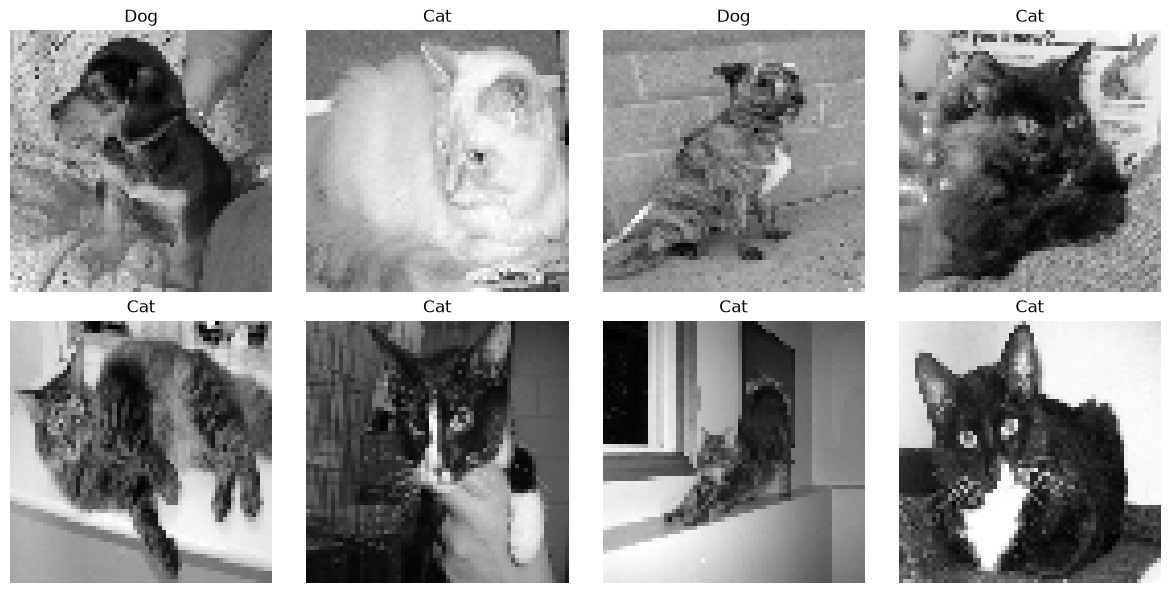

In [31]:
# ============================================================
# Step 7.4 : Display Preprocessed Images
# ============================================================

plt.figure(figsize=(12, 6))

for i in range(8):

    plt.subplot(2,4,i+1)

    plt.imshow(processed_images[i], cmap="gray")

    title = "Cat" if labels[i] == 0 else "Dog"

    plt.title(title)

    plt.axis("off")

plt.tight_layout()
plt.show()

# Step 8: HOG Feature Extraction

Support Vector Machines cannot directly process images.

Therefore, each image is converted into a numerical feature vector using Histogram of Oriented Gradients (HOG).

HOG captures the edge and shape information of an image while reducing dimensionality, making it well suited for classical machine learning algorithms such as SVM.

In [33]:
# ============================================================
# Step 8.1 : HOG Feature Extraction
# ============================================================

from skimage.feature import hog

hog_features = []

print("=" * 60)
print("Extracting HOG Features...")
print("=" * 60)

for image in processed_images:

    features = hog(
        image,
        orientations=9,
        pixels_per_cell=(8,8),
        cells_per_block=(2,2),
        block_norm="L2-Hys"
    )

    hog_features.append(features)

hog_features = np.array(hog_features)

print("Feature Extraction Completed!")
print("Feature Matrix Shape :", hog_features.shape)

Extracting HOG Features...
Feature Extraction Completed!
Feature Matrix Shape : (4000, 1764)


# Step 9: Train-Test Split

Before training the Support Vector Machine (SVM), the dataset is divided into training and testing sets.

- Training Set (80%): Used to train the model.
- Testing Set (20%): Used to evaluate the model's performance on unseen data.

A random state is used to ensure reproducibility of the results.

In [34]:
# ============================================================
# Step 9.1 : Train-Test Split
# ============================================================

from sklearn.model_selection import train_test_split

X = hog_features
y = labels

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42,
    stratify=y
)

print("=" * 60)
print("Training & Testing Dataset")
print("=" * 60)

print("Training Samples :", X_train.shape)
print("Testing Samples  :", X_test.shape)

Training & Testing Dataset
Training Samples : (3200, 1764)
Testing Samples  : (800, 1764)


# Step 10: Feature Scaling

Support Vector Machines are sensitive to the scale of input features.

StandardScaler standardizes every feature so that it has:
- Mean = 0
- Standard Deviation = 1

This improves the convergence and performance of the SVM classifier.

In [37]:
# ============================================================
# Step 10 : Feature Scaling
# ============================================================

from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()

X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

print("=" * 60)
print("Feature Scaling Completed!")
print("=" * 60)

print("Training Shape :", X_train.shape)
print("Testing Shape  :", X_test.shape)

Feature Scaling Completed!
Training Shape : (3200, 1764)
Testing Shape  : (800, 1764)


# Step 11: Train the Support Vector Machine

A Support Vector Machine (SVM) classifier is trained using the HOG feature vectors.

The RBF kernel is selected because it performs well on non-linear image classification problems.

In [38]:
# ============================================================
# Step 11 : Train SVM
# ============================================================

from sklearn.svm import SVC
import time

print("=" * 60)
print("Training Support Vector Machine...")
print("=" * 60)

start = time.time()

svm_model = SVC(
    kernel="rbf",
    C=10,
    gamma="scale"
)

svm_model.fit(X_train, y_train)

end = time.time()

print("\nTraining Completed Successfully!")

print(f"\nTraining Time : {end-start:.2f} seconds")

Training Support Vector Machine...

Training Completed Successfully!

Training Time : 12.82 seconds


In [39]:
# ============================================================
# Step 12 : Prediction
# ============================================================

print("=" * 60)
print("Predicting Test Dataset...")
print("=" * 60)

y_pred = svm_model.predict(X_test)

print("Prediction Completed!")

Predicting Test Dataset...
Prediction Completed!


# Step 13: Model Evaluation

The trained model is evaluated using multiple performance metrics:

- Accuracy
- Precision
- Recall
- F1-score
- Confusion Matrix

These metrics help measure how well the classifier performs on unseen images.

In [40]:
# ============================================================
# Step 13 : Accuracy
# ============================================================

from sklearn.metrics import accuracy_score

accuracy = accuracy_score(y_test, y_pred)

print("=" * 60)
print("Model Accuracy")
print("=" * 60)

print(f"Accuracy : {accuracy*100:.2f}%")

Model Accuracy
Accuracy : 73.25%


In [41]:
# ============================================================
# Step 13.1 : Classification Report
# ============================================================

from sklearn.metrics import classification_report

print(classification_report(
    y_test,
    y_pred,
    target_names=["Cat","Dog"]
))

              precision    recall  f1-score   support

         Cat       0.74      0.72      0.73       400
         Dog       0.73      0.74      0.74       400

    accuracy                           0.73       800
   macro avg       0.73      0.73      0.73       800
weighted avg       0.73      0.73      0.73       800



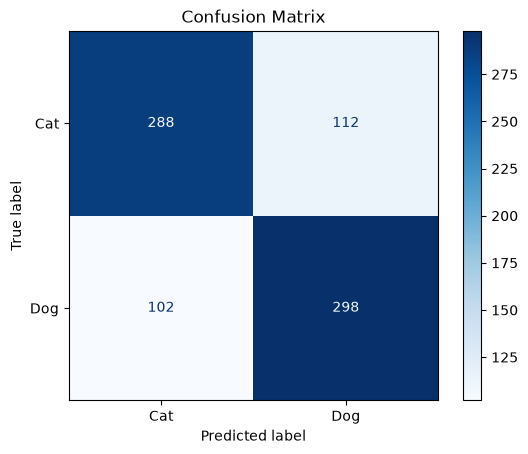

In [42]:
# ============================================================
# Step 13.2 : Confusion Matrix
# ============================================================

from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay

cm = confusion_matrix(y_test, y_pred)

disp = ConfusionMatrixDisplay(
    confusion_matrix=cm,
    display_labels=["Cat","Dog"]
)

disp.plot(cmap="Blues")

plt.title("Confusion Matrix")

plt.show()

# Step 14: Save the Trained Model

After training the Support Vector Machine (SVM), the trained model and the fitted StandardScaler are saved to disk.

Saving the model allows it to be reused later without retraining, making deployment through the Flask web application much faster.

In [43]:
# ============================================================
# Step 14.1 : Save SVM Model
# ============================================================

import os
import joblib

model_folder = "../models"

os.makedirs(model_folder, exist_ok=True)

joblib.dump(svm_model, os.path.join(model_folder, "svm_model.pkl"))

print("✅ SVM Model Saved Successfully!")

✅ SVM Model Saved Successfully!


In [44]:
# ============================================================
# Step 14.2 : Save StandardScaler
# ============================================================

joblib.dump(scaler, os.path.join(model_folder, "scaler.pkl"))

print("✅ Scaler Saved Successfully!")

✅ Scaler Saved Successfully!


In [45]:
# ============================================================
# Step 14.3 : Verify Saved Files
# ============================================================

print("="*60)

print("Saved Files")

print("="*60)

print(os.listdir(model_folder))

Saved Files
['scaler.pkl', 'svm_model.pkl']


# Step 16: Create Evaluation Image Pool

To make the web application faster and more responsive, we create a fixed evaluation pool containing 100 randomly selected images.

Instead of searching through all 25,000 images for every request, the backend randomly selects an image from this smaller pool.

In [35]:
# ============================================================
# Step 16 : Create Evaluation Pool
# ============================================================

import shutil
import random
import os

random.seed(42)

evaluation_folder = "../evaluation_images"

os.makedirs(evaluation_folder, exist_ok=True)

evaluation_images = random.sample(image_files, 100)

for image in evaluation_images:

    source = os.path.join(train_path, image)
    destination = os.path.join(evaluation_folder, image)

    shutil.copy(source, destination)

print("=" * 60)
print("Evaluation Dataset Created Successfully!")
print("=" * 60)
print("Images Copied :", len(os.listdir(evaluation_folder)))

Evaluation Dataset Created Successfully!
Images Copied : 100
